[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


All libraries imported successfully!
Dataset loaded!  Shape: (1600000, 2)
  sentiment                                               text
0  negative  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1  negative  is upset that he can't update his Facebook by ...
2  negative  @Kenichan I dived many times for the ball. Man...
3  negative    my whole body feels itchy and like its on fire 
4  negative  @nationwideclass no, it's not behaving at all....

--- Sentiment Count ---
sentiment
negative    800000
positive    800000
Name: count, dtype: int64

--- Missing Values ---
sentiment    0
text         0
dtype: int64


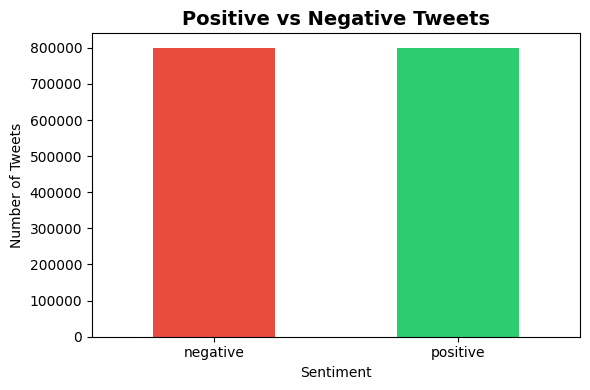

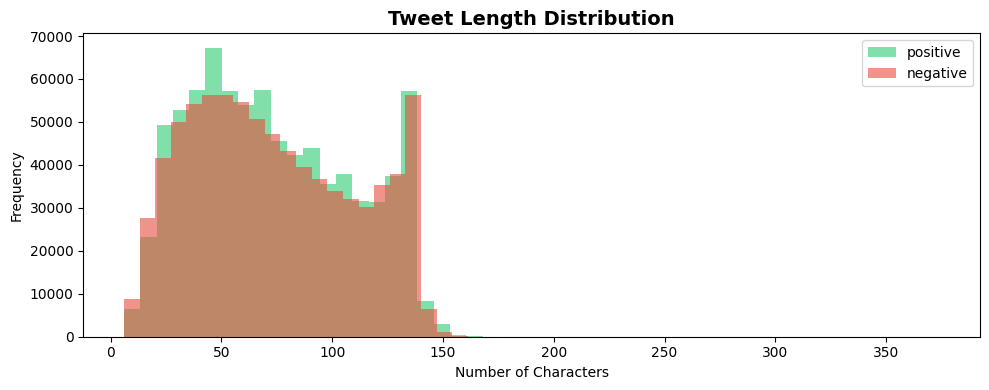

EDA charts saved!
Cleaning tweets... this may take 1-2 minutes...

--- Before Cleaning ---
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

--- After Cleaning ---
thats bummer shoulda got david carr third day

Cleaning done!  Rows remaining: 1,592,290


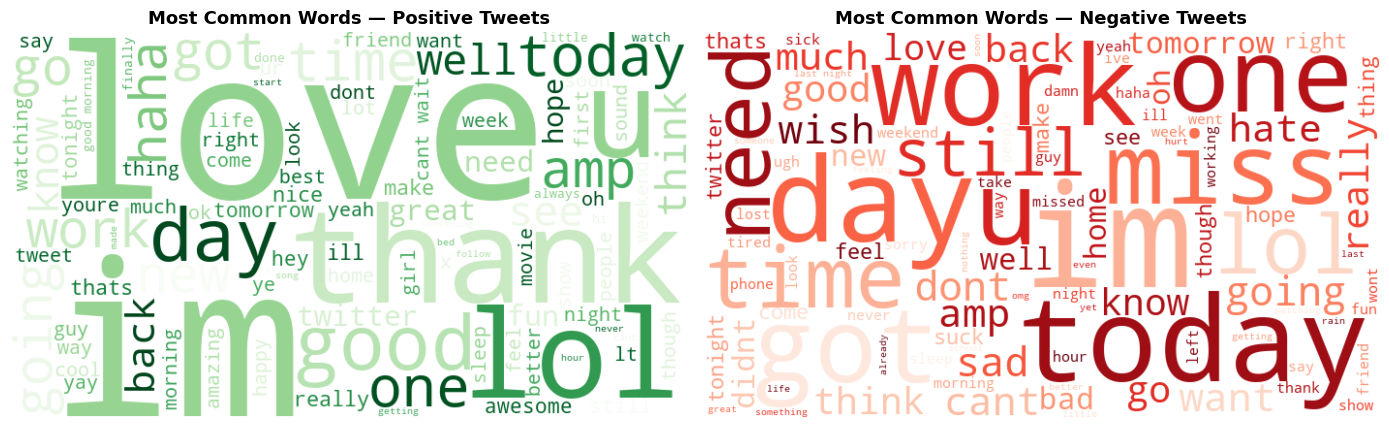

WordCloud saved as chart3_wordcloud.png
  Data split done!
   Training samples : 1,273,832
   Testing samples  : 318,458

Converting text to numbers using TF-IDF...
 TF-IDF done!  Feature matrix shape: (1273832, 50000)

Training the model... please wait...
Model training complete!

Model Accuracy: 79.54%

Full Evaluation Report
              precision    recall  f1-score   support

    negative       0.80      0.78      0.79    158780
    positive       0.79      0.81      0.80    159678

    accuracy                           0.80    318458
   macro avg       0.80      0.80      0.80    318458
weighted avg       0.80      0.80      0.80    318458



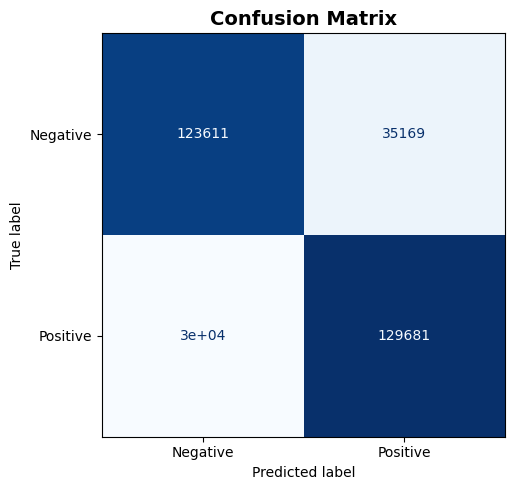

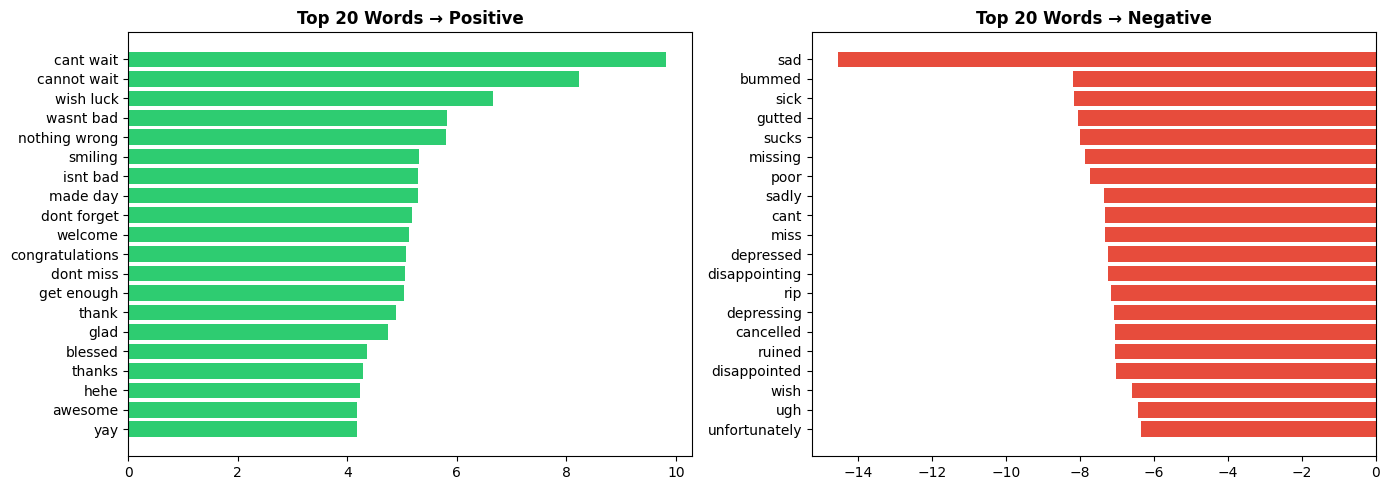

All evaluation charts saved!

--- Testing with sample sentences ---

  Text       : I absolutely love this phone, it is amazing!
  Sentiment  : POSITIVE 😊
  Confidence : 95.1%
  ------------------------------------------------
  Text       : This movie was a complete waste of my time
  Sentiment  : POSITIVE 😊
  Confidence : 61.7%
  ------------------------------------------------
  Text       : Just had the best meal of my life!
  Sentiment  : POSITIVE 😊
  Confidence : 91.0%
  ------------------------------------------------
  Text       : I hate Mondays so much
  Sentiment  : NEGATIVE 😞
  Confidence : 92.9%
  ------------------------------------------------
  Text       : The weather today is okay I guess
  Sentiment  : NEGATIVE 😞
  Confidence : 63.2%
  ------------------------------------------------

Your custom prediction

  Text       : Type your own sentence here!
  Sentiment  : POSITIVE 😊
  Confidence : 73.2%
  ------------------------------------------------

Model saved as  se

In [4]:
# TWITTER SENTIMENT ANALYSIS 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import nltk

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
from nltk.corpus import stopwords

print("All libraries imported successfully!")


#  LOAD THE DATASET

df = pd.read_csv(
    "C:/Users/LENOVO/Downloads/archive (34)/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    header=None
)

# Give columns proper names
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

# Keep only what we need
df = df[['sentiment', 'text']]

# Convert labels:  0 → negative  |  4 → positive
df['sentiment'] = df['sentiment'].replace({0: 'negative', 4: 'positive'})

print(f"Dataset loaded!  Shape: {df.shape}")
print(df.head())

# EXPLORE THE DATA (EDA)

# Basic info
print("\n--- Sentiment Count ---")
print(df['sentiment'].value_counts())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# Chart 1: Positive vs Negative count 
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(
    kind='bar',
    color=['#E74C3C', '#2ECC71'],
    edgecolor='none'
)
plt.title('Positive vs Negative Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_sentiment_count.png', dpi=150)
plt.show()

# Chart 2: Tweet length distribution
df['tweet_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 4))
for label, color in [('positive', '#2ECC71'), ('negative', '#E74C3C')]:
    df[df['sentiment'] == label]['tweet_length'].plot(
        kind='hist', bins=50, alpha=0.6, color=color, label=label
    )
plt.title('Tweet Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_tweet_length.png', dpi=150)
plt.show()

print("EDA charts saved!")

# CLEAN THE TEXT
# Raw tweets have noise: links, @mentions, #hashtags, symbols.
# We remove all of that so only meaningful words remain.

stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'@\w+', '', text)               # remove @mentions
    text = re.sub(r'#', '', text)                  # remove # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # keep letters only
    text = text.lower().strip()                     # lowercase
    words = [w for w in text.split() if w not in stop_words]  # remove stop words
    return ' '.join(words)

print("Cleaning tweets... this may take 1-2 minutes...")
df['clean_text'] = df['text'].apply(clean_tweet)

# Remove rows where cleaning left an empty string
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Show before / after example
print("\n--- Before Cleaning ---")
print(df['text'].iloc[0])
print("\n--- After Cleaning ---")
print(df['clean_text'].iloc[0])

print(f"\nCleaning done!  Rows remaining: {len(df):,}")

# WORDCLOUD (Visual EDA)
# Shows the most common words in positive and negative tweets.

pos_text = ' '.join(df[df['sentiment'] == 'positive']['clean_text'].sample(20000, random_state=42))
neg_text = ' '.join(df[df['sentiment'] == 'negative']['clean_text'].sample(20000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, text, title, cmap in [
    (axes[0], pos_text, 'Most Common Words — Positive Tweets', 'Greens'),
    (axes[1], neg_text, 'Most Common Words — Negative Tweets',  'Reds')
]:
    wc = WordCloud(width=700, height=400, background_color='white', colormap=cmap, max_words=100)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_wordcloud.png', dpi=150)
plt.show()

print("WordCloud saved as chart3_wordcloud.png")

# SPLIT DATA INTO TRAIN AND TEST
# 80% of data → model learns from this (training)
# 20% of data → we test on this (the model has never seen it)

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"  Data split done!")
print(f"   Training samples : {len(X_train):,}")
print(f"   Testing samples  : {len(X_test):,}")

# CONVERT TEXT TO NUMBERS (TF-IDF)
# Machine learning models cannot read words.
# TF-IDF converts each word into a number (score).
# Words that are rare but appear a lot in one tweet
# get a HIGH score — they are more meaningful.

print("\nConverting text to numbers using TF-IDF...")

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f" TF-IDF done!  Feature matrix shape: {X_train_vec.shape}")

# TRAIN THE MODEL (Logistic Regression)
# The model studies the training tweets + their labels.
# It learns: which word patterns → positive, which → negative.

print("\nTraining the model... please wait...")

model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
model.fit(X_train_vec, y_train)

print("Model training complete!")

# EVALUATE THE MODEL
# We test the model on the 20% data it has never seen.
# This tells us how well it performs on new tweets.

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nFull Evaluation Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_confusion_matrix.png', dpi=150)
plt.show()

# Top words chart
feature_names = tfidf.get_feature_names_out()
coefs         = model.coef_[0]

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_pos_idx], [coefs[i] for i in top_pos_idx], color='#2ECC71')
axes[0].set_title('Top 20 Words → Positive', fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh([feature_names[i] for i in top_neg_idx], [coefs[i] for i in top_neg_idx], color='#E74C3C')
axes[1].set_title('Top 20 Words → Negative', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart5_top_words.png', dpi=150)
plt.show()

print("All evaluation charts saved!")

# PREDICT ON YOUR OWN TEXT
# Type any sentence and the model tells you:
# positive or negative, and how confident it is.

def predict_sentiment(text):
    cleaned     = clean_tweet(text)
    vectorized  = tfidf.transform([cleaned])
    prediction  = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    confidence  = probability[list(model.classes_).index(prediction)] * 100
    emoji       = '😊' if prediction == 'positive' else '😞'

    print(f"  Text       : {text}")
    print(f"  Sentiment  : {prediction.upper()} {emoji}")
    print(f"  Confidence : {confidence:.1f}%")
    print("  " + "-" * 48)

print("\n--- Testing with sample sentences ---\n")
predict_sentiment("I absolutely love this phone, it is amazing!")
predict_sentiment("This movie was a complete waste of my time")
predict_sentiment("Just had the best meal of my life!")
predict_sentiment("I hate Mondays so much")
predict_sentiment("The weather today is okay I guess")

# --- Try your own text below ---
print("\nYour custom prediction\n")
my_text = "Type your own sentence here!"   
predict_sentiment(my_text)

# SAVE THE MODEL
# Save the trained model so we don't have to retrain it every time you open the notebook.

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("\nModel saved as  sentiment_model.pkl")
print("Vectorizer saved as  tfidf_vectorizer.pkl")
print("\n Successfully done the project!")